# Resource estimation for simulating a 2D Ising Model Hamiltonian

In this Python notebook we demonstrate how to estimate the resources for quantum dynamics, specifically the simulation of an Ising model Hamiltonian on an $N \times N$ 2D
lattice using a *fourth-order Trotter Suzuki product formula* assuming a 2D
qubit architecture with nearest-neighbor connectivity.

First, we load the qsharp package.

In [1]:
import qsharp

## Background: 2D Ising model

The Ising model is a mathematical model of ferromagnetism in a lattice (in our case a 2D square lattice) with two kinds of terms in the Hamiltonian: (i) an interaction term between adjacent sites and (ii) an external magnetic field acting at each site. For our purposes, we consider a simplified version of the model where the interaction terms have the same strength and the external field strength is the same at each site.
Formally, the Ising model Hamiltonian on an $N \times N$ lattice we consider is formulated as:

$$
H = \underbrace{-J \sum_{i, j} Z_i Z_j}_{B} - \underbrace{h \sum_j X_j}_{A}
$$
where $J$ is the interaction strength, $h$ is external field strength.

In [10]:
from qsharp.magnets.geometry import Patch2D
from qsharp.magnets.models import IsingModel, HeisenbergModel

# Because we want a transverse field Ising model, we need to include self-loops in the lattice
model = IsingModel(Patch2D(5, 5, self_loops=True), h = 0.5, J=1.0)
print (model)

Ising model with 2 terms on 25 qubits (h=0.5, J=1.0).


## Trotter expansion

The time evolution $e^{-iHt}$ for the Hamiltonian is simulated with the fourth-order product formula so that any errors in simulation are sufficiently small. Essentially, this is done by simulating the evolution for small slices of time $\Delta$ and repeating this for `nSteps` $= t/\Delta$ to obtain the full time evolution. The Trotter-Suzuki formula for higher orders can be recursively defined using a *fractal decomposition*. In particular, the fourth order formula $U_4(\Delta)$ can be constructed using the second-order one $U_2(\Delta)$ as follows.
$$
\begin{aligned}
U_2(\Delta) & = e^{-iA\Delta/2} e^{-iB\Delta} e^{-iA\Delta/2}; \\
U_4(\Delta) & = U_2(p\Delta)U_2(p\Delta)U_2((1 - 4p)\Delta)U_2(p\Delta)U_2(p\Delta); \\
p & = (4 - 4^{1/3})^{-1}.
\end{aligned}
$$

In [12]:
import math

from qsharp.magnets.trotter import TrotterExpansion, fourth_order_trotter_suzuki

t = 10
dt = 0.5

trotter = TrotterExpansion(fourth_order_trotter_suzuki, model, time=dt, num_steps=math.ceil(t/dt))
circuit = trotter.cirq()

circuit

cirq.CircuitOperation(
    circuit=cirq.FrozenCircuit([
        cirq.Moment(
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(7))), qubits=(cirq.LineQubit(7),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(2))), qubits=(cirq.LineQubit(2),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(12))), qubits=(cirq.LineQubit(12),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(8))), qubits=(cirq.LineQubit(8),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(16))), qubits=(cirq.LineQubit(16),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(17))), qubits=(cirq.LineQubit(17),), exponent_neg=0.0014843817645604966, exponent_pos=0),

## Application wrapper

Presently the circuit is Cirq code and can be used for any purpose (e.g. simulation). To obtain resource estimates we wrap this in a QRE Application instance. The `CirqApplication` subclass does this automatically from any `Cirq.Circuit` instance.

In [13]:
from qsharp.qre.application import CirqApplication

app = CirqApplication(circuit)
app_query = app.q()

app

CirqApplication(circuit_or_qasm=cirq.CircuitOperation(
    circuit=cirq.FrozenCircuit([
        cirq.Moment(
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(7))), qubits=(cirq.LineQubit(7),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(2))), qubits=(cirq.LineQubit(2),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(12))), qubits=(cirq.LineQubit(12),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(8))), qubits=(cirq.LineQubit(8),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(16))), qubits=(cirq.LineQubit(16),), exponent_neg=0.0014843817645604966, exponent_pos=0),
            cirq.PauliStringPhasor(((1+0j)*cirq.X(cirq.LineQubit(17))), qubits=(cirq.LineQubit(17),), exponent_neg=0.00148

## Majorana architectures

A QRE `Architecture` is a container for an Instruction Set Architecture (ISA): a list of instructions the hardware supports. The Majorana architecture supports single-qubit and two-qubit measurements in the X- and Z-bases, as well as a timing-based T-gate. The `Majorana` subclass provides the ISA for a user specified measurement error rate. Note the asymetry in the assumed error rates for measurement/state preparation versus the unitary T-gate.

In [14]:
from qsharp.qre.models import Majorana

arch = Majorana(error_rate=1e-5)
arch

Instruction,Arity,Space,Time (ns),Error Rate
MEAS_X,1,1,1000,1.00e-05
MEAS_XX,2,2,1000,1.00e-05
MEAS_Z,1,1,1000,1.00e-05
MEAS_ZZ,2,2,1000,1.00e-05
PREP_X,1,1,1000,1.00e-05
PREP_Z,1,1,1000,1.00e-05
T,1,1,1000,1.50e-02


## Creating Application and ISA Queries

The core of the sytem is modeled through trace queries (from the top) and isa_queries (from the bottom).

The trace query applies layouts (`ISATransform` instances) to convert the operations from the application into logical operations supported by error correction codes and magic state factories. Here we expand fine rotation gates into T-gates using circuit synthesis. The `PSSPC` layout takes as an argument the options for the number of T-gates used per rotation. QRE will enumerate over this list and compute the error rate associated to each approximation, and the contribution to the overall error rate. The `LatticeSurgery` layout links the cat-state layout (which requires instruction MULTI_PAULI_MEAS) to the logical operation provided by the code (LATTICE_SURGERY).

The ISA query provides the specific options for the code, in this case `ThreeAux` (an instance of the surface code). It provides the LATTICE_SURGERY instruction required by the trace. Magic states are not provided by the code, and so the `RoundBasedFactory` is a generic model that provides magic state distillation.

In [15]:
from qsharp.qre import estimate, PSSPC, LatticeSurgery
from qsharp.qre.models import ThreeAux, RoundBasedFactory

trace_query = (
    app_query
    * PSSPC.q(num_ts_per_rotation=[16,17,18,19])
    * LatticeSurgery.q()
)

isa_query = (
    ThreeAux.q(distance=[11, 13, 15, 17, 19])
    * RoundBasedFactory.q(code_query=ThreeAux.q(distance=[5,7,11,13,15,17,19]))
)

results = estimate(app, arch, isa_query, trace_query, max_error=0.01, name="Majorana e-5, 3-aux")


## Visualizing and understanding the results

### Result summary table

Canonically the number of physical qubits, runtime for a shot, and the shot error rate are presented. QRE reports only on configuration of the parameters that are Pareto optimal in time and space (and satsify the specified error rate in the `estimate` command). We add additional columns for information about these configurations.

Notice the tradeoff between space (number of qubits) and time (runtime) is governed entirely by the selection of code distance. The higher code distance means the algorithm runs more slowly and the compute register is larger. But as a side effect we need far fewer magic state factories, and hence the total qubit count goes down!

In [16]:
from qsharp.qre.instruction_ids import LATTICE_SURGERY
from qsharp.qre.property_keys import NUM_TS_PER_ROTATION, DISTANCE, PHYSICAL_COMPUTE_QUBITS

results.add_column("compute_distance", lambda entry: entry.source[LATTICE_SURGERY].instruction[DISTANCE])
results.add_column("compute qubits", lambda entry: entry.properties[PHYSICAL_COMPUTE_QUBITS])
results.add_column("num_ts_per_rotation", lambda entry: entry.properties[NUM_TS_PER_ROTATION])
results.add_factory_summary_column()
results.add_column("cycle_time", lambda entry: entry.source[LATTICE_SURGERY].instruction.expect_time(1))

results.as_frame()

,name,qubits,runtime,error,compute_distance,compute qubits,num_ts_per_rotation,factories,cycle_time
0,"Majorana e-5, 3-aux",150826,0 days 00:00:00.857920,0.003459,13,44418,16,47×T,56000
1,"Majorana e-5, 3-aux",156266,0 days 00:00:00.735360,0.003459,11,31746,16,55×T,48000


### Throttling the algorithm

Seeing that we want the algorithm to run more slowly to conserve on qubit count, we can simply increase the runtime of each lattice surgery step. This can be done directly as an argument to the `LatticeSurgery` layout. Again we provide a list of options; QRE will examine each of these and report Pareto-optimal configurations.

In [17]:
new_trace_query = (
    app_query
    * PSSPC.q(slow_down_factor = 3.0, num_ts_per_rotation=[15,16,17,18])
    * LatticeSurgery.q(slow_down_factor = [1.0*j for j in range(2,31)])
)

new_results = estimate(app, arch, isa_query, new_trace_query, max_error=0.01, name="new Majorana e-5, 3-aux")
new_results.add_column("compute_distance", lambda entry: entry.source[LATTICE_SURGERY].instruction[DISTANCE])
new_results.add_column("compute qubits", lambda entry: entry.properties[PHYSICAL_COMPUTE_QUBITS])
new_results.add_column("num_ts_per_rotation", lambda entry: entry.properties[NUM_TS_PER_ROTATION])
new_results.add_factory_summary_column()

new_results.as_frame()

,name,qubits,runtime,error,compute_distance,compute qubits,num_ts_per_rotation,factories
0,"new Majorana e-5, 3-aux",55710,0 days 00:00:37.286400,0.004639,7,44390,17,5×T
1,"new Majorana e-5, 3-aux",57974,0 days 00:00:31.072000,0.004627,7,44390,17,6×T
2,"new Majorana e-5, 3-aux",60238,0 days 00:00:26.100480,0.004618,7,44390,17,7×T
3,"new Majorana e-5, 3-aux",62502,0 days 00:00:23.614720,0.004613,7,44390,17,8×T
4,"new Majorana e-5, 3-aux",64766,0 days 00:00:21.128960,0.004608,7,44390,17,9×T
5,"new Majorana e-5, 3-aux",67030,0 days 00:00:18.643200,0.004604,7,44390,17,10×T
6,"new Majorana e-5, 3-aux",69294,0 days 00:00:17.400320,0.004601,7,44390,17,11×T
7,"new Majorana e-5, 3-aux",71558,0 days 00:00:16.157440,0.004599,7,44390,17,12×T
8,"new Majorana e-5, 3-aux",73822,0 days 00:00:14.914560,0.004597,7,44390,17,13×T
9,"new Majorana e-5, 3-aux",76086,0 days 00:00:13.671680,0.004594,7,44390,17,14×T


# Create plots

We can use matplotlib to create nice plots of our tradeoff curve.

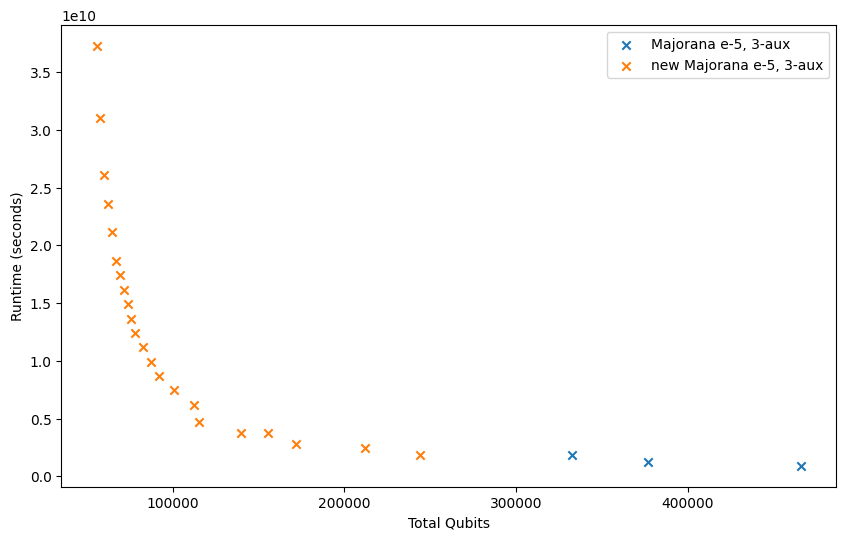

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

combined = pd.concat([results.as_frame(), new_results.as_frame()])
plt.figure(figsize=(10, 6))
for name, group in combined.groupby("name"):
    plt.scatter(group["qubits"], group["runtime"], marker='x', label=name)
plt.xlabel("Total Qubits")
plt.ylabel("Runtime (seconds)")
plt.legend()
plt.show()